# EDA

Authors: Hana Magyarová, Lenka Husárová, Martin Mislovič

In [1]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import random
import numpy as np
from collections import Counter

## Basic stats


Dataset statistics:
Number of classes: 5749
Total number of images: 13233
Average images per class: 2.30
Min images in a class: 1
Max images in a class: 530

Top 5 classes by image count:
               Class  ImageCount
0      George_W_Bush         530
1       Colin_Powell         236
2         Tony_Blair         144
3    Donald_Rumsfeld         121
4  Gerhard_Schroeder         109


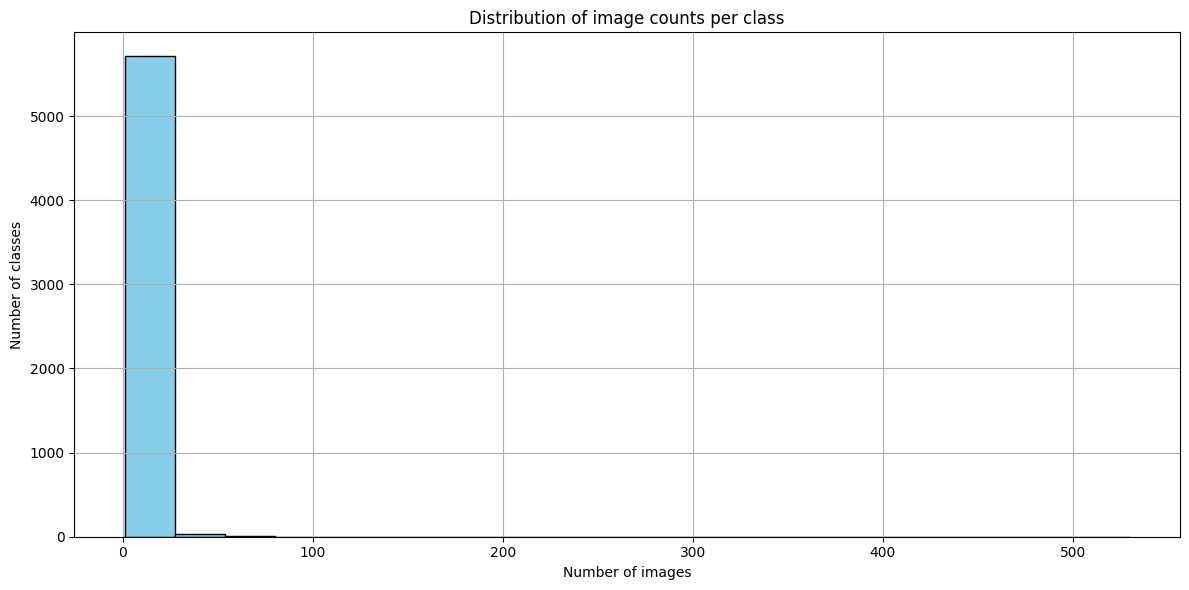

In [2]:
base_path = "data/"

class_counts = {
    folder: len(os.listdir(os.path.join(base_path, folder)))
    for folder in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, folder))
}

df = pd.DataFrame(list(class_counts.items()), columns=["Class", "ImageCount"])

df = df.sort_values(by="ImageCount", ascending=False).reset_index(drop=True)

print("Dataset statistics:")
print(f"Number of classes: {len(df)}")
print(f"Total number of images: {df['ImageCount'].sum()}")
print(f"Average images per class: {df['ImageCount'].mean():.2f}")
print(f"Min images in a class: {df['ImageCount'].min()}")
print(f"Max images in a class: {df['ImageCount'].max()}")
print("\nTop 5 classes by image count:")
print(df.head())

plt.figure(figsize=(12, 6))
plt.hist(df['ImageCount'], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of image counts per class")
plt.xlabel("Number of images")
plt.ylabel("Number of classes")
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
min_count = df["ImageCount"].min()
num_classes_with_min = (df["ImageCount"] == min_count).sum()

print(f"Minimum image count: {min_count}")
print(f"Number of classes with this minimum count: {num_classes_with_min}")

Minimum image count: 1
Number of classes with this minimum count: 4069


The most represented are classes with only 1 image, of which there are 4096, which represents slightly more than 71% of the classes from the entire dataset. 

## Choose random images

We decided to pick and check some random images from random 5 classes.

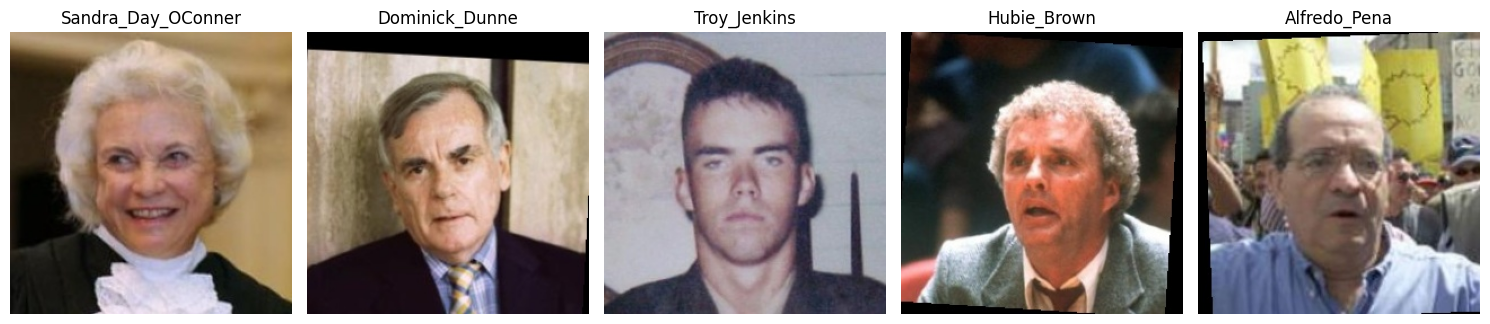

In [4]:
def show_sample_images(base_path, class_counts, n=5):
    selected_classes = random.sample(list(class_counts.keys()), min(n, len(class_counts)))
    
    plt.figure(figsize=(15, 5))  

    for i, cls in enumerate(selected_classes):
        folder_path = os.path.join(base_path, cls)
        image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if not image_files:
            continue  

        img_path = os.path.join(folder_path, random.choice(image_files))
        
        img = cv2.imread(img_path)
        if img is None:
            continue 
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images("data/", class_counts, n=5)

## Check image resolution

In [5]:
def get_image_resolutions(base_path):
    resolutions = []
    
    for cls in os.listdir(base_path):
        cls_path = os.path.join(base_path, cls)
        if not os.path.isdir(cls_path):
            continue
        
        for img_name in os.listdir(cls_path):
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            
            img_path = os.path.join(cls_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue  
            
            h, w = img.shape[:2]
            resolutions.append((w, h)) 

    return Counter(resolutions)


base_path = "data/"
resolution_counts = get_image_resolutions(base_path)


print(f"Total unique resolutions: {len(resolution_counts)}")
for res, count in resolution_counts.most_common(5):
    print(f"Resolution {res[0]}x{res[1]}: {count} images")


Total unique resolutions: 1
Resolution 250x250: 13233 images


## Key findings
During the initial exploration of our image dataset, we performed a basic statistical analysis and visual inspection of the data. The dataset consists of individual folders for each class (person), with a varying number of images per class. Using exploratory data analysis (EDA), we found noticeable class imbalance, where some individuals have significantly more images than others.


We found out, that:
- some images appear to be pre-augmented, showing slight rotations, flips, or cropped variations within the same class

- the image quality varies across samples, including differences in resolution, sharpness, and lighting conditions

- uniform image resolution (250x250)

- noticeable class imbalance, where some individuals have significantly more images than others

- most classes contain only 1 image (more than 71% of the dataset)